In [1]:
# Heart Disease Prediction using Machine Learning
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
## Load Dataset
df = pd.read_csv("C:/Users/GOPICHAND/OneDrive/Desktop/InternSpark/TASK-1/heart.csv")
df.head()
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


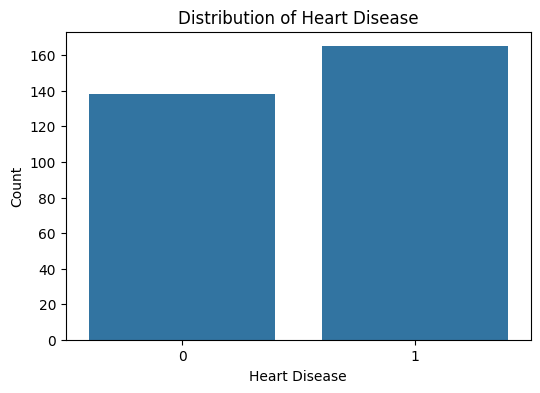

In [3]:
## Exploratory Data Analysis
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="target")
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

In [4]:
df.isnull().sum()
df.duplicated().sum()

np.int64(1)

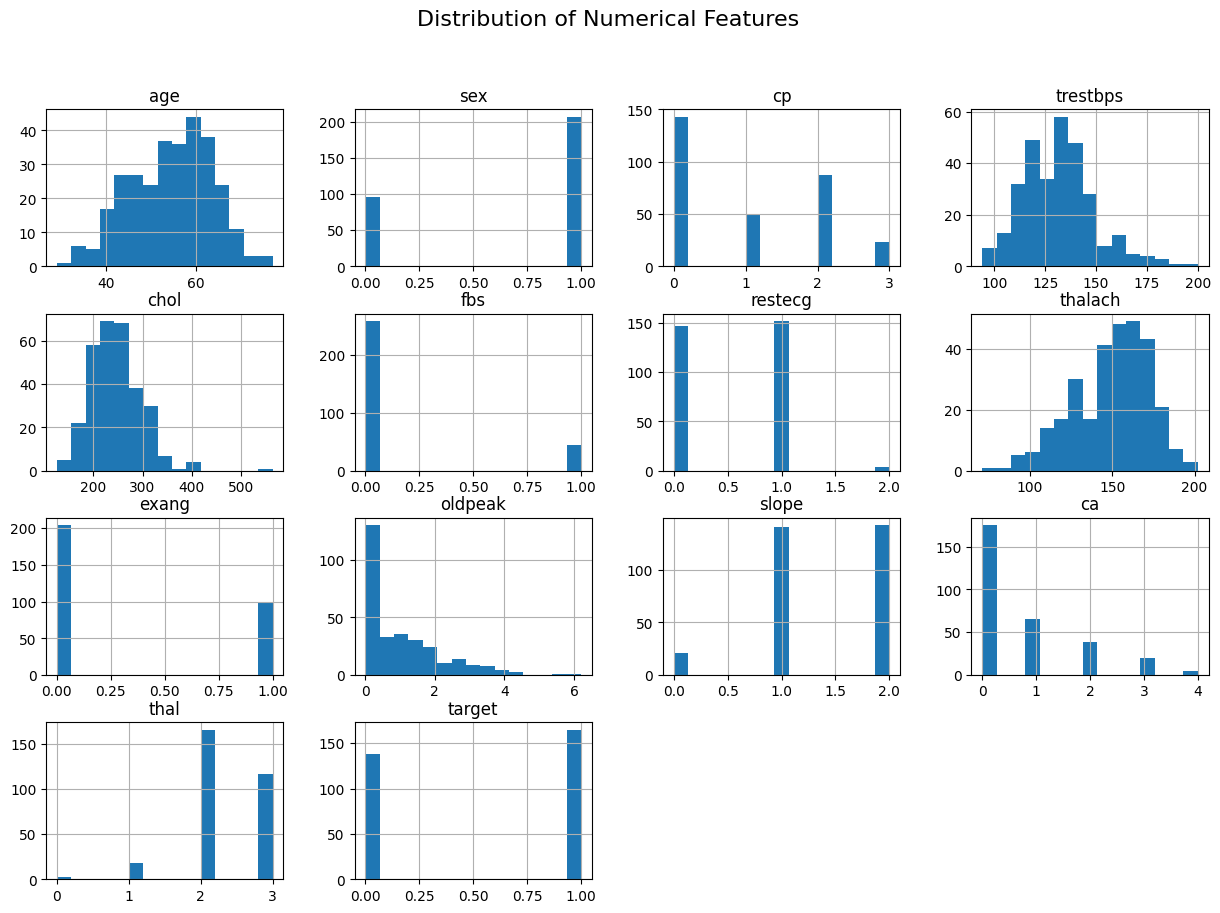

In [5]:
df.hist(figsize=(15,10), bins=15)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.show()

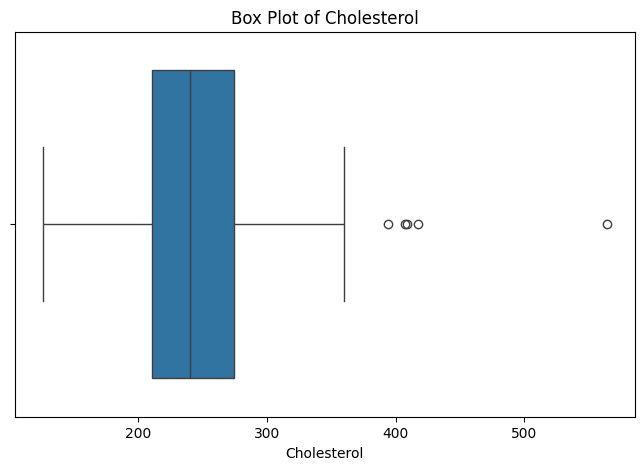

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["chol"])

plt.title("Box Plot of Cholesterol")

plt.xlabel("Cholesterol")

plt.show()

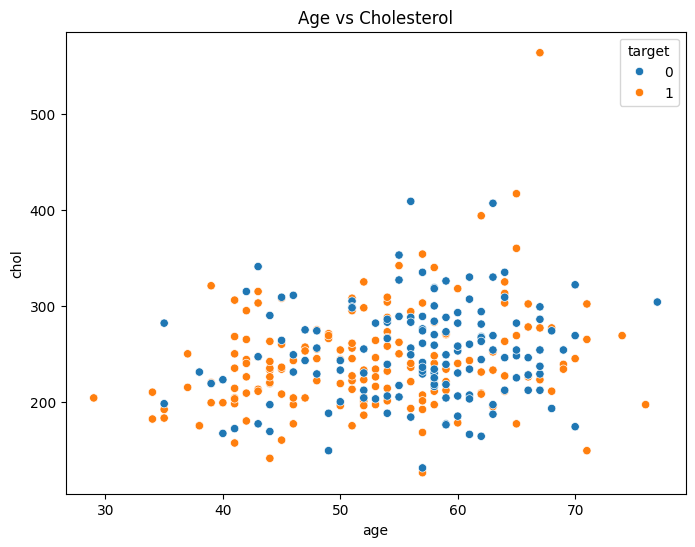

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="age",
    y="chol",
    hue="target"
)

plt.title("Age vs Cholesterol")

plt.show()

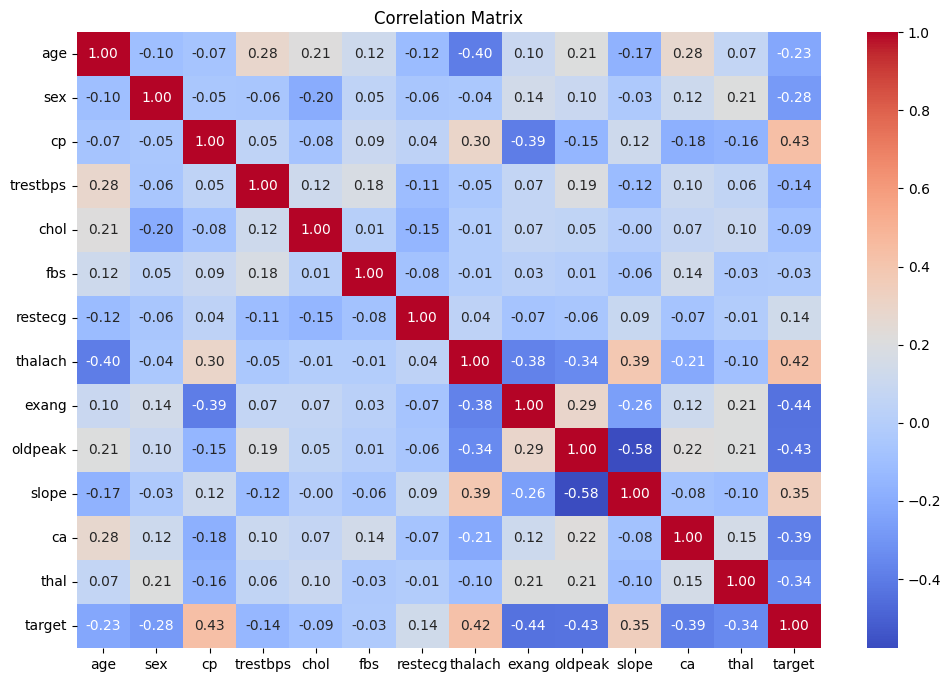

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [9]:
## Data Preprocessing
X = df.drop("target", axis=1)
y = df["target"]
print(X.shape)
print(y.shape)

(303, 13)
(303,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (242, 13)
X_test : (61, 13)
y_train: (242,)
y_test : (61,)


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
## Logistic Regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(y_pred[:10])

[0 1 1 0 1 1 1 0 0 0]


In [13]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8524590163934426


In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[25  4]
 [ 5 27]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [15]:
## Cross Validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=5,
    scoring='accuracy'
)
print("Cross Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.80327869 0.86885246 0.85245902 0.86666667 0.75      ]
Average CV Accuracy: 0.8282513661202187


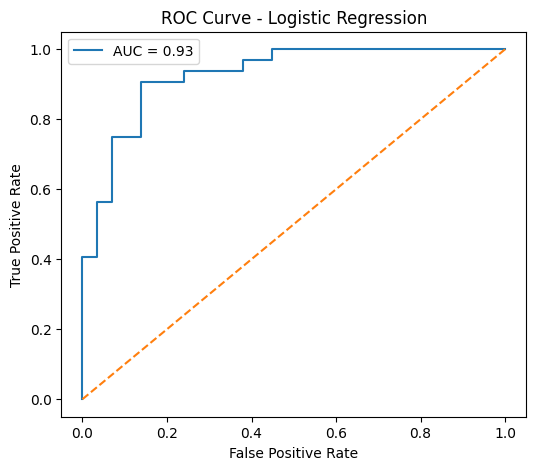

ROC-AUC Score: 0.9267241379310345


In [16]:
## ROC-AUC Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()
print("ROC-AUC Score:", auc_score)

In [17]:
## Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [18]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8360655737704918


In [19]:
rf_cm = confusion_matrix(y_test, rf_pred)
print(rf_cm)
print(classification_report(y_test, rf_pred))
rf_prob = rf_model.predict_proba(X_test)[:, 1]

[[24  5]
 [ 5 27]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



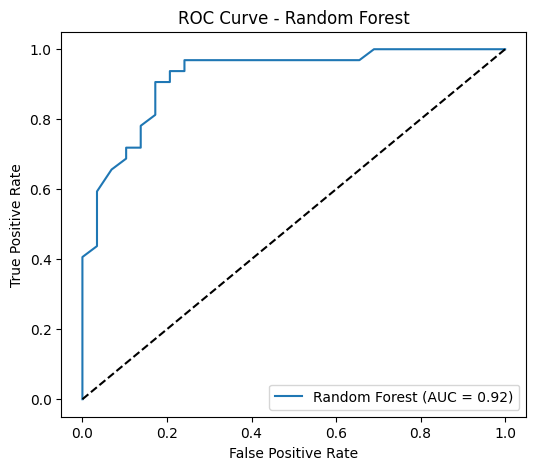

Random Forest ROC-AUC: 0.9202586206896551


In [20]:
#AUC-ROC for RANDOM FOREST
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
plt.figure(figsize=(6,5))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()
print("Random Forest ROC-AUC:", rf_auc)

In [21]:
## Model Comparison
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.85, 0.84],
    "Precision": [0.87, 0.84],
    "Recall": [0.84, 0.84],
    "F1 Score": [0.86, 0.84],
    "ROC-AUC": [0.93,0.92]
})
comparison.style.highlight_max(axis=0)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.850000,0.870000,0.840000,0.860000,0.930000
1,Random Forest,0.840000,0.840000,0.840000,0.840000,0.920000


## Conclusion
In this project, two machine learning algorithms—Logistic Regression and Random Forest—were implemented to predict heart disease. 
Both models were evaluated using Accuracy, Precision, Recall, F1-Score, Cross-Validation, and ROC-AUC. 
Logistic Regression achieved an accuracy of 85% and an excellent ROC-AUC score of 0.93, outperforming Random Forest on this dataset. 
Based on the evaluation metrics, Logistic Regression was selected as the best-performing model for heart disease prediction.